In [1]:
import torch
import wandb
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

from utility import *

In [ ]:
class CompleteTripletDataset(Dataset):
    def __init__(self, image_folder_dataset, min_images_per_person: int = 2):
        self.dataset = image_folder_dataset
        self.min_images_per_person = min_images_per_person

        # Create a dict containing indices for every class
        self.class_indices = {}
        for index, (_, label) in enumerate(self.dataset):
            if label not in self.class_indices:
                self.class_indices[label] = []
            self.class_indices[label].append(index)

        # Create a list of valid anchor classes
        self.valid_anchor_classes = [
            class_index for class_index, indices in self.class_indices.items() 
            if len(indices) > self.min_images_per_person
        ]

        self.triplets = []
        for anchor_class in self.valid_anchor_classes:
            anchor_class_indices = self.class_indices[anchor_class]
            class_triplets = []

            # Prejdi vsetky anchors pre danu triedu
            for i, anchor_index in enumerate(anchor_class_indices):
                # Ku anchoru pridaj nahodne pozitivny image
                positive_indices = [p for j, p in enumerate(anchor_class_indices) if j != i]
                positive_index = random.choice(positive_indices)

                # A nahodne negativny image
                
                negative_classes = [p for p, _ in self.class_indices.items() if p != anchor_class]
                #negative_classes = [p for p in self.valid_anchor_classes if p != anchor_class]
                negative_class = random.choice(negative_classes)
                negative_index = random.choice(self.class_indices[negative_class])

                class_triplets.append((anchor_index, positive_index, negative_index))

                ''' Toto bol pokus robit vsetky kombinacie ale to je s tak vela images nemožné
                
                for j, positive_index in enumerate(anchor_class_indices):
                    if i == j:
                        continue

                    
                    for negative_class, negative_indices in self.class_indices.items():
                        if negative_class == anchor_class:
                            continue
                        for negative_index in negative_indices:
                            class_triplets.append((anchor_index, positive_index, negative_index))
                    '''
            
            
            self.triplets.extend(class_triplets)
        



    def __len__(self):
        return len(self.triplets)
    
    
    def __getitem__(self, idx):
        anchor_index, positive_index, negative_index = self.triplets[idx]

        anchor_img, _ = self.dataset[anchor_index]
        positive_img, _ = self.dataset[positive_index]
        negative_img, _ = self.dataset[negative_index]

        return anchor_img, positive_img, negative_img
        

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

face_dataset = ImageFolder(root="./data", transform=transform)

total_size = len(face_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size  

train_dataset, val_dataset, test_dataset = random_split(
    face_dataset, [train_size, val_size, test_size]
)

triplet_dataset = CompleteTripletDataset(train_dataset)
validation_dataset = CompleteTripletDataset(val_dataset)
test_dataset = CompleteTripletDataset(test_dataset)

In [4]:
print(f"The dataset contains {len(triplet_dataset)} triplets")

The dataset contains 5744 triplets


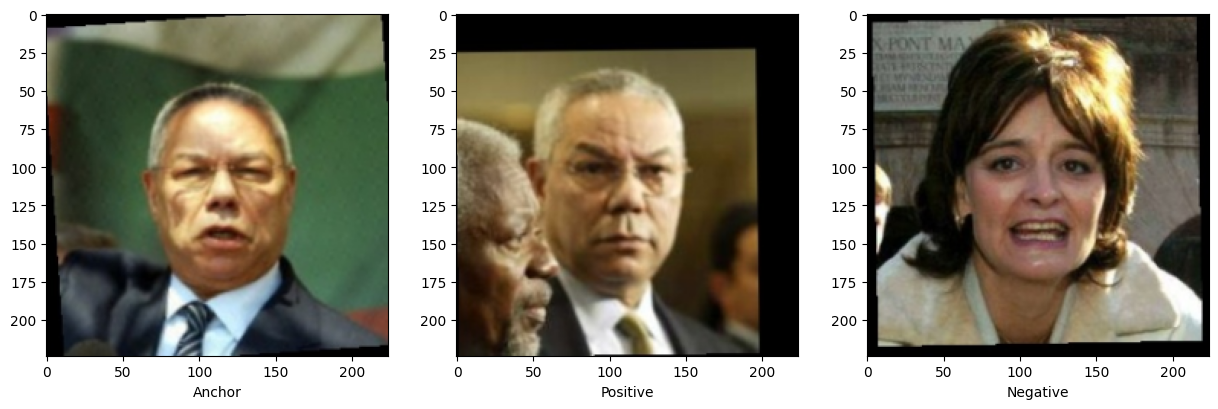

In [5]:
visualize_triplets(triplet_dataset, 1000)

In [6]:
train_loader = DataLoader(triplet_dataset, batch_size=8)
val_loader = DataLoader(validation_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

In [7]:
class ResidualBlock(nn.Module):
    expanstion = 1

    def __init__(self, input_channels: int, output_channels: int, stride: int = 1):
        super().__init__()
        self.normal_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(output_channels)
        )

        self.skip_conntect = nn.Sequential()

        if stride != 1 or input_channels != self.expanstion * output_channels:
            self.skip_conntect = nn.Sequential(
                nn.Conv2d(input_channels, self.expanstion * output_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expanstion * output_channels)
            )
    

    def forward(self, x):
        out = self.normal_path(x)
        out += self.skip_conntect(x)
        out = F.relu(out)
        return out

In [8]:
class NeuralNet(nn.Module):
    def __init__(self, embedding_size: int):
        super(NeuralNet, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 64, stride=1),

            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=2),

            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=2),

            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512, stride=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fully_connected = nn.Sequential(
            nn.Linear(512, embedding_size)
        )

    
    def forward(self, x: torch.Tensor):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        x = F.normalize(x, p=2, dim=1)
        return x
    

In [9]:
def select_device():
    if torch.cuda.is_available():
        print("Currently using: Nvidia CUDA")
        device = torch.device("cuda")
    elif torch.mps.is_available():
        print("Currently using: Apple Metal Performance Shaders")
        device = torch.device("mps")
    else:
        print("Currently using: CPU")
        device = torch.device("cpu")
    return device

device = select_device()

Currently using: Apple Metal Performance Shaders


In [20]:
def train(model: nn.Module, loss_function: nn.Module, optimizer, scheduler, epochs, use_wandb: bool = True):
    for epoch in range(epochs):
        print(f"--- Epoch {epoch + 1} ---")
        losses = []
        val_losses = []
        with tqdm(train_loader) as progress:
            for anchor_img, positive_img, negative_img in progress:
                optimizer.zero_grad()

                anchor_img = anchor_img.to(device)
                positive_img = positive_img.to(device)
                negative_img = negative_img.to(device)

                anchor_embed = model.forward(anchor_img)
                positive_embed = model.forward(positive_img)
                negative_embed = model.forward(negative_img)

                loss = loss_function(anchor_embed, positive_embed, negative_embed)
                losses.append(loss.item())
                progress.set_postfix(mean_loss = f"{sum(losses)/len(losses)}")
                loss.backward()
                optimizer.step()
                
        with tqdm(val_loader) as progress:
            distances = []
            labels = []
            for anchor_img, positive_img, negative_img in progress:
                with torch.no_grad():
                    anchor_img = anchor_img.to(device)
                    positive_img = positive_img.to(device)
                    negative_img = negative_img.to(device)

                    anchor_embed = model.forward(anchor_img)
                    positive_embed = model.forward(positive_img)
                    negative_embed = model.forward(negative_img)

                    loss = loss_function(anchor_embed, positive_embed, negative_embed)
                    val_losses.append(loss.item())
                    progress.set_postfix(mean_loss = f"{sum(val_losses)/len(val_losses)}")

                    batch_size = anchor_embed.shape[0]

                    distances.extend(torch.sum((anchor_embed - positive_embed) ** 2, dim=1).cpu().numpy())
                    labels.extend([1] * batch_size)
                    distances.extend(torch.sum((anchor_embed - negative_embed) ** 2, dim=1).cpu().numpy())
                    labels.extend([0] * batch_size)
                
            distances = np.array(distances)
            labels = np.array(labels)

            fars = []
            frrs = []
            thresholds = np.linspace(distances.min(), distances.max(), 1000)

            for threshold in thresholds:
                predictions = (distances < threshold).astype(int)
                TP = np.sum((predictions == 1) & (labels == 1))
                TN = np.sum((predictions == 0) & (labels == 0))
                FP = np.sum((predictions == 1) & (labels == 0))
                FN = np.sum((predictions == 0) & (labels == 1))
                FAR = FP / (FP + TN + 1e-8)
                FRR = FN / (TP + FN + 1e-8)
                fars.append(FAR)
                frrs.append(FRR)
            fars = np.array(fars)
            frrs = np.array(frrs)
            min_index = np.argmin(np.abs(fars - frrs))
            val_eer = (fars[min_index] + frrs[min_index]) / 2
            val_eer_threshold = thresholds[min_index]
            print(f"Validation EER: {val_eer}")
            print(f"Validation EER Threshold: {val_eer_threshold}")

            if use_wandb:
                wandb.log({
                    "validation_eer": val_eer,
                    "validation_loss": sum(val_losses)/len(val_losses)
                    }
                )
            scheduler.step()


In [16]:
class ShadowLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        anchor_norm = anchor.norm(dim=1, keepdim=True)

        pa_p = (anchor * positive).sum(dim=1, keepdim=True) / anchor_norm
        pa_n = (anchor * negative).sum(dim=1, keepdim=True) / anchor_norm

        p = (anchor_norm - pa_p).abs()
        n = (anchor_norm - pa_n).abs()

        loss = torch.clamp(p - n + self.margin, min=0.0)
        return loss.mean()

In [11]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "validation_eer",
        "goal": "minimize"
    },
    "parameters": {
        "margin":{
            "min": 0.0,
            "max": 1.0,
        },
        "lr": {
            "min": 0.00001,
            "max": 0.001
        },
        "weight_decay": {
            "min": 0.0001,
            "max": 1.0
        },
        "embedding_size": {
            "min": 4,
            "max": 256
        }
    }
}

In [12]:
def sweep():
    wandb.init()
    config = wandb.config
    model: nn.Module = NeuralNet(config.embedding_size).to(device)
    loss = nn.TripletMarginLoss(margin=config.margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
    train(model, loss, optimizer, scheduler, 20)

In [13]:
#sweep_id = wandb.sweep(sweep_config, project="nsiete-project-3")
#wandb.agent(sweep_id, function=sweep, count=10)

In [21]:
model: nn.Module = NeuralNet(128).to(device)
loss = ShadowLoss(margin=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

train(model, loss, optimizer, scheduler, 20, False)

--- Epoch 1 ---


100%|██████████| 42/42 [00:05<00:00,  7.71it/s, mean_loss=0.496651020078432]  


Validation EER: 0.5030303030150597
Validation EER Threshold: 0.6556029319763184
--- Epoch 2 ---


100%|██████████| 42/42 [00:04<00:00,  9.34it/s, mean_loss=0.4456515085129511] 


Validation EER: 0.4424242424108356
Validation EER Threshold: 0.7222748398780823
--- Epoch 3 ---


100%|██████████| 42/42 [00:05<00:00,  7.63it/s, mean_loss=0.4397534346651463] 


Validation EER: 0.3984848484727732
Validation EER Threshold: 0.3646087944507599
--- Epoch 4 ---


 13%|█▎        | 96/718 [00:34<03:43,  2.78it/s, mean_loss=0.20034545318533978]


KeyboardInterrupt: 

In [ ]:
def test(model):
    with tqdm(test_loader) as progress:
        with torch.no_grad():
            distances = []
            labels = []
            for anchor_img, positive_img, negative_img in progress:
                anchor_img = anchor_img.to(device)
                positive_img = positive_img.to(device)
                negative_img = negative_img.to(device)

                anchor_embed = model.forward(anchor_img)
                positive_embed = model.forward(positive_img)
                negative_embed = model.forward(negative_img)

                batch_size = anchor_embed.shape[0]

                distances.extend(torch.sum((anchor_embed - positive_embed) ** 2, dim=1).cpu().numpy())
                labels.extend([1] * batch_size)
                distances.extend(torch.sum((anchor_embed - negative_embed) ** 2, dim=1).cpu().numpy())
                labels.extend([0] * batch_size)
            
            distances = np.array(distances)
            labels = np.array(labels)

            fars = []
            frrs = []
            thresholds = np.linspace(distances.min(), distances.max(), 1000)

            for threshold in thresholds:
                predictions = (distances < threshold).astype(int)
                TP = np.sum((predictions == 1) & (labels == 1))
                TN = np.sum((predictions == 0) & (labels == 0))
                FP = np.sum((predictions == 1) & (labels == 0))
                FN = np.sum((predictions == 0) & (labels == 1))
                FAR = FP / (FP + TN + 1e-8)
                FRR = FN / (TP + FN + 1e-8)
                fars.append(FAR)
                frrs.append(FRR)
            fars = np.array(fars)
            frrs = np.array(frrs)
            min_index = np.argmin(np.abs(fars - frrs))
            eer = (fars[min_index] + frrs[min_index]) / 2
            eer_threshold = thresholds[min_index]

            print(f"EER: {eer}")
            print(f"EER Threshold {eer_threshold}")

In [ ]:
test(model)

100%|██████████| 45/45 [00:03<00:00, 14.74it/s]

EER: 0.2857142857062825
EER Threshold 0.625680148601532
